## Spectral Analysis
Besides ERPs, the primary way neuroscientists understand EEG signals is to look for oscillations, or rhythmic fluctations in the voltage of an EEG signal. Some fluctuations occur very fast, cycling dozens of times in the span of a second, while others will see only 3 or 4 cycles a second. Breaking down EEG according to the contributions of oscillations at various frequencies is key to electrophysiological analysis. 

There are many ways to break down an EEG signal into its component frequencies and measure the contribution of each. Two examples of ways to break down an EEG signal are the Fourier Transform and Mortlet Wavelet method. The Fourier Transform is the foundational tool for spectral analysis, and the Morelet wavelet method is key for analyzing time-frequency information. In this assignment, you'll implement these techniques and get an introduction to MNE, a software package for analyzing neural timeseries data.

<center>
<img src="http://neurosky.com/wp-content/uploads/2015/05/Screen-Shot-2015-05-14-at-10.41.17-AM.png" width=300>
</center>

## Fourier Series Composition / Decomposition 

One of the most important principles of signal analysis is the notion that all signal patterns can be decomposed into a combination of sine and cosine components (where sometimes an infinite number of these are required for accurate representation).  Linear combinations of these sine and cosine components will then reproduce the original signal:

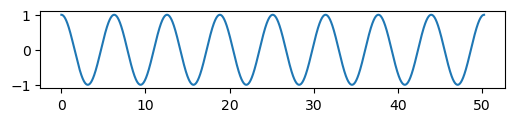

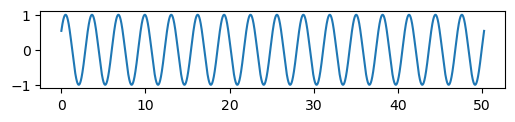

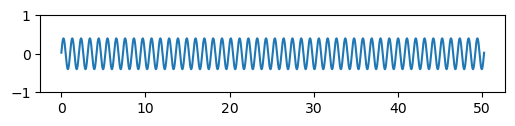

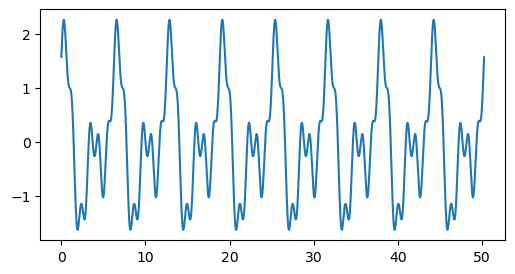

In [1]:
import numpy as np
%matplotlib inline
import pylab as plt

x = np.arange(0,8*2*np.pi,0.001)
plt.figure(figsize=(6,1))
y1 = np.cos(x)
plt.plot(x, y1)
plt.figure(figsize=(6,1))
y2 = np.cos(2*x-1)
plt.plot(x, y2)
plt.figure(figsize=(6,1))
y3 = 0.4*np.cos(6*x-1.5)
plt.ylim(-1,1)
plt.plot(x, y3)
plt.figure(figsize=(6,3))
plt.plot(x, y1+y2+y3)

With a Fourier Transform, the final plot above can be reversed to obtain the sinusoidal components used to create it.  With enough sinusoidal components, all signals can be analyzed in this way, even if they are non-repeating.  However, for signals which change their patterns substantially with time, we are often interested in examining the sinusoidal components characteristic of a restricted portions of the signal.  For this we will use a technique called wavelet analysis. In the Assignment, you will not use Fourier Transforms, but it remains important to understand the broader concept. 

## Frequency Analysis (Optional)

Here we will visually examine the mathematical foundations of Fourier and Wavelet analyses of power and phase at various frequencies.  We will do this by examining the cosine and sine terms (or "real" and "imaginary" terms) in the complex plane, where the cosine/real term is one axis, and the sine/imaginary term is another axis.  This is justified by the Euler relation described in Chapter 4 of the EHM text.
\begin{equation}
e^{i\phi} = \cos(\phi) + i\sin(\phi)
\end{equation}

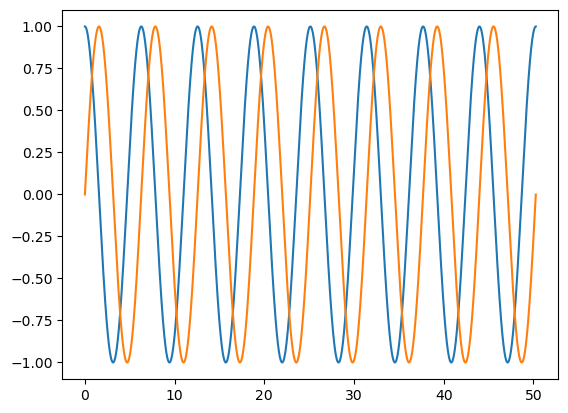

In [2]:
import numpy as np
%matplotlib inline
import pylab as plt

x = np.arange(0,8*2*np.pi,0.001)
plt.plot(x, np.cos(x))
plt.plot(x, np.sin(x))

## Circles not Triangles (Optional) 

The better way to think about the trig functions is not in terms of triangles, but as circles:

<center>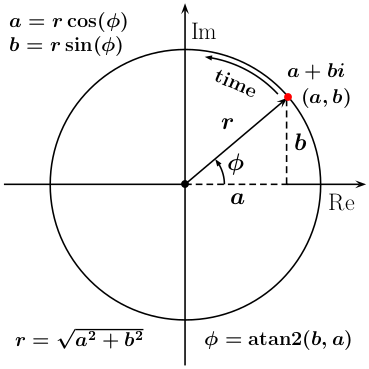</center>

From this perspective of a time varying signal, time moves angularly around the origin, and a sinusoidal oscillation is simply a projection of such a circle onto a line. The cos and sin functions are simply the x and y projections, but you could draw your axes at any rotation (time offset).  And in fact, all time varying signals can be represented on such a plot, with the radial distance away from the origin (the amplitude) being the signal strength at that point in time.  It is instructive to take this spiraling around the origin, and stretch it out into a helix.

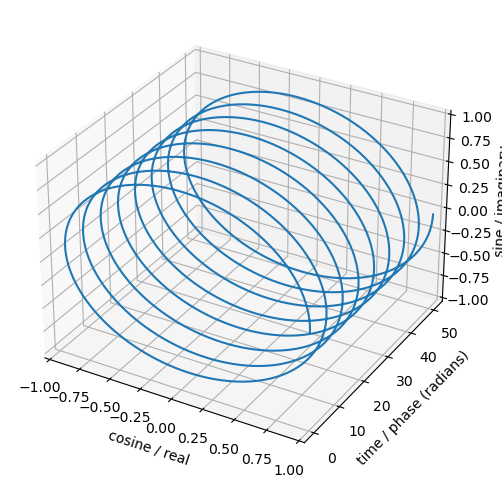

In [3]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_xlabel('cosine / real')
ax.set_zlim(-1,1)
ax.set_zlabel('sine / imaginary')
ax.set_ylabel('time / phase (radians)')
ax.plot(np.cos(x), x, np.sin(x))

a = 0.4619445214722019
b = 0.19133974381900626
M = 0.5000036384696661
phi (set to  0.39269908169872414 ) = 0.392691797813932


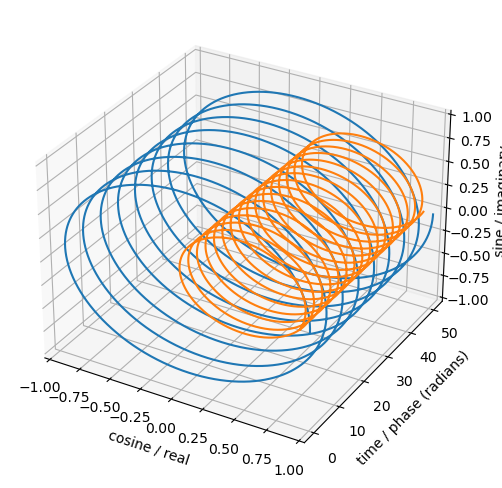

In [4]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_xlabel('cosine / real')
ax.set_zlim(-1,1)
ax.set_zlabel('sine / imaginary')
ax.set_ylabel('time / phase (radians)')
ax.plot(np.cos(x), x, np.sin(x))
func = np.cos(x-np.pi/8)   # Function analyzed defined here  ***
ax.plot(func*np.cos(x), x, func*np.sin(x))
a = np.mean(func*np.cos(x))
b = np.mean(func*np.sin(x))
M = np.sqrt(a*a + b*b)
print('a =', a)
print('b =', b)
print('M =', M)
print('phi (set to ', np.pi/8, ') =', np.arctan2(b,a))

a = 5.148038077820446e-06
b = -1.2418546526398915e-09
M = 5.14803822760595e-06


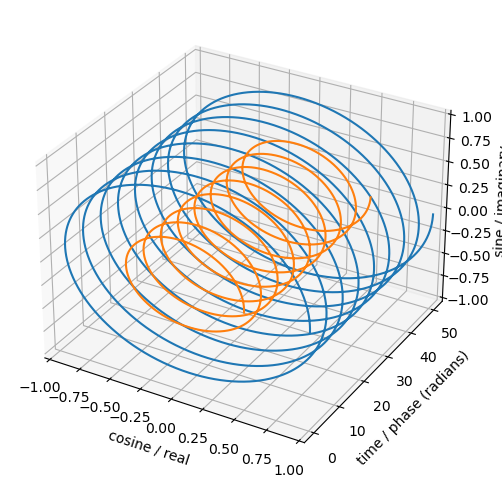

In [5]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_xlabel('cosine / real')
ax.set_zlim(-1,1)
ax.set_zlabel('sine / imaginary')
ax.set_ylabel('time / phase (radians)')
ax.plot(np.cos(x), x, np.sin(x))
func = 0.5   # Function analyzed defined here, flat 0.5 for all phase values  ***
ax.plot(func*np.cos(x), x, func*np.sin(x))
a = np.mean(func*np.cos(x))
b = np.mean(func*np.sin(x))
M = np.sqrt(a*a + b*b)
print('a =', a)
print('b =', b)
print('M =', M)

a = -1.98941595587647e-05
b = 1.1790346458828112e-08
M = 1.989416305256038e-05
phi = 3.141


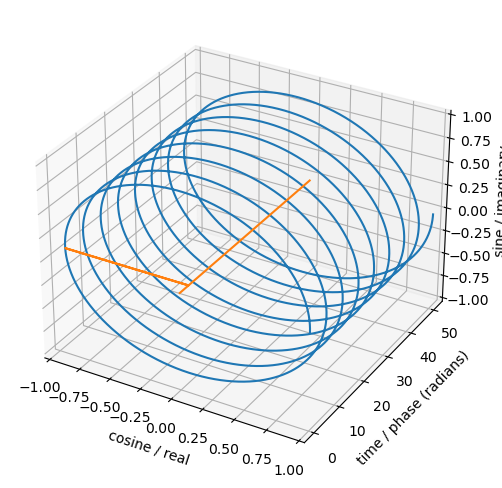

In [6]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_xlabel('cosine / real')
ax.set_zlim(-1,1)
ax.set_zlabel('sine / imaginary')
ax.set_ylabel('time / phase (radians)')
ax.plot(np.cos(x), x, np.sin(x))

func = np.zeros(len(x))    # Function analyzed defined here, delta function  ***
func[int(1000*np.pi)] = 1  # at the first phase value of pi, with x step 0.001

ax.plot(func*np.cos(x), x, func*np.sin(x))
a = np.mean(func*np.cos(x))
b = np.mean(func*np.sin(x))
M = np.sqrt(a*a + b*b)
print('a =', a)
print('b =', b)
print('M =', M)
print('phi =', np.arctan2(b,a))

# Wavelets

Unlike the Fourier transform, which decomposes a signal into infinite sine and cosine waves extending across all time, Morlet wavelets allow us to study how frequencies change over time by localizing them within a window. The Morlet wavelet achieves this by multiplying a sine or cosine function by a Gaussian envelope, effectively restricting its frequency analysis to a small portion of time. This makes it especially useful for non-stationary signals, like EEG, where frequency content shifts dynamically. Complete Morlet wavelets include additional correction terms to preserve both phase and power, but the essential idea is a balance between temporal and spectral resolution that the standard Fourier transform lacks.

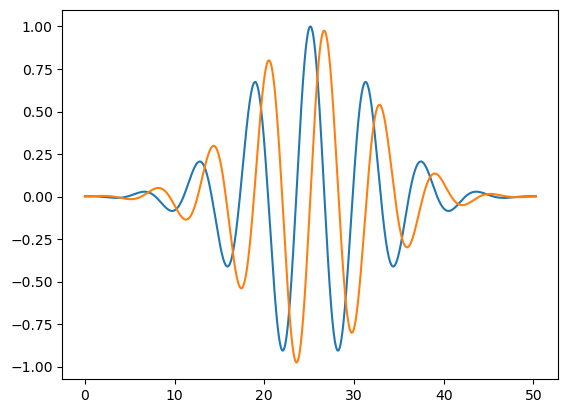

In [7]:
simple_morlet_cos = np.exp(-(1/2)*((x-x[int(len(x)/2)])/7)**2) * np.cos(x)
simple_morlet_sin = np.exp(-(1/2)*((x-x[int(len(x)/2)])/7)**2) * np.sin(x)

plt.plot(x, simple_morlet_cos)
plt.plot(x, simple_morlet_sin)

## Optional

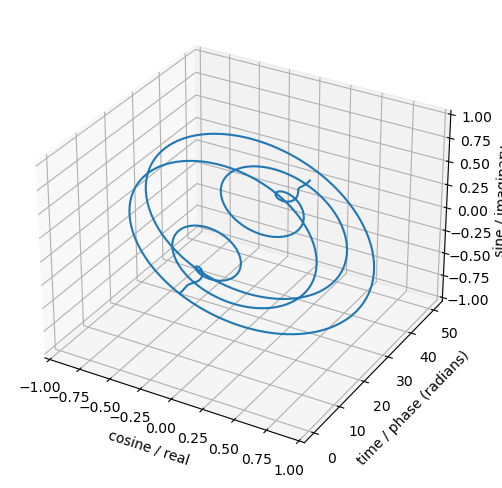

In [8]:
simple_morlet = np.exp(-(1/2)*((x-x[int(len(x)/2)])/7)**2) * (np.cos(x), np.sin(x))

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_xlabel('cosine / real')
ax.set_zlim(-1,1)
ax.set_zlabel('sine / imaginary')
ax.set_ylabel('time / phase (radians)')
ax.plot(simple_morlet[0], x, simple_morlet[1])

A signal multiplied by this Morlet Wavelet functions similarly to the Fourier case, except that only signal pieces in the Gaussian window are analyzed.  To examine another period of time, the wavelet is shifted and the next time period is analyzed.

## Tips for Spectral Power Analyses of EEG

### What is a Spectral Power Analysis? 

Spectral Power Density (SPD) analysis measures how the power of a signal is distributed across different frequencies. It shows which frequency components contain the most energy, helping identify rhythmic patterns or dominant oscillations in neural data like EEG. In practice, SPD analysis transforms a time-domain signal into the frequency domain, revealing both noise characteristics and meaningful brain rhythms such as alpha or gamma activity.


* We're often interested in **contrasts between conditions**, e.g. rememebered vs. not-remembered, or stimulus vs. baseline, etc. Interpreting raw power values can be difficult and should be done with care. 
* Many filters, like the Morlet wavelet, induce edge effects. Be sure to add an appropriately-sized **buffer** and remove it after filtering! Edge effects occur when filtering near the start or end of a signal, where there isn’t enough data for the filter to operate properly, leading to artificial distortions. A buffer is extra data added before and after the segment of interest (often mirrored or extended portions of the signal) to protect the main time window from these distortions.
* **Line noise** and harmonics (60 Hz, 120 Hz) can contaminate analyses of high-frequency activity. Re-referencing can mitigate it somewhat, but either avoid analyzing frequencies around 60 and 120 Hz or apply a notch filter to remove residual line noise. A notch filter removes power within a very narrow frequency band—such as 60 Hz line noise—while leaving surrounding frequencies largely unaffected, making it ideal for eliminating electrical interference without distorting the rest of the signal.

### Important, but not directly applicable to Assignments 

* **Nyquist limit**: The maximum frequency that can be resolved is equal to the sampling rate divided by two (F_s/2). Subjects are often sampled at 500 Hz or 1000 Hz, corresponding to maximum resolved frequencies of 250 Hz or 500 Hz. In practice, try not to get too close to the limit anyway. This is typically not an issue for any recent subjects, since our maximum frequency of interest is rarely >200 Hz or so.
* **Bandwidth**: The lowest frequency that can be resolved in a timeseries, equal to 1/T, where T is the duration of the available time window. (Same as the smallest-possible frequency spacing.)
* There is a **fundamental trade-off** between time resolution and frequency resolution. With greater frequency resolution comes worse time resolution, and vice versa. So resolving frequencies within ~1 Hz of each other, like in the theta range, is possible, but you will not be able to make judgments about the timing of effects beyond ~1 second. Try to use time windows that contain at least **3 cycles** of your lowest frequency of interest. 
* In the figure below, samples (squares) of various signals (curves) are shown. Subfigure d. shows an example of aliasing, in which a frequency component above the Nyquist limit spuriously appears as a lower frequency component in the set of discrete-time samples.
<center>
<img src="https://github.com/esolomon/PythonBootcamp2019/blob/master/figures/nyquist.png?raw=true" width=700>
</center>

## Implementing time-frequency analyses in Python (See bold) 

There are several Python toolboxes that have good implementations of various spectral decomposition methods. Here we'll focus on **MNE Python** (MNE: MEG 'n' EEG; MEG is similar to scalp EEG but uses magnetic signals rather than electrical ones), a suite of tools for analysis of neural timeseries data (https://martinos.org/mne/stable/index.html). **PTSA** (Python Time Series Analyis) is another Python-based timeseries toolbox, designed by former members of the Computational Memory Lab, that features a very fast implementation of the Morlet Wavelet Transform. (https://github.com/pennmem/ptsa)

**You will only have to rely on one of these libraries for the workshop. PTSA is exclusively used by our lab while MNE is the system that is traditionally used in labs across the country. It's up to you which you prefer.**

In [9]:
# imports
import mne
import ptsa
import numpy as np
import matplotlib.pyplot as plt
from ptsa.data.filters import morlet
from ptsa.data.filters import ButterworthFilter
import sys
sys.path.append("dependencies/bidsreader")
from bidsreader import CMLBIDSReader as BIDSReader
from bidsreader import (
    filter_events_df_by_trial_types,
    mne_epochs_to_ptsa,
)

# Data comes from the cluster or OpenNeuro -- you are asked. See cml_data.py
sys.path.insert(0, ".")
from cml_data import get_bids_root


### MNE Python
Let's take a look at doing some basic spectral analyses with MNE. First, we'll load up the same dataset we've been working with the past few assignments. 

In [10]:
# Specify which subject and experiment we want
sub = 'R1111M'
task = 'FR1'
sess = 0

# Asks where to read the data from. If you choose OpenNeuro it will show
# the download size and ask first (~1.5 GB here, cached afterwards).
root = get_bids_root(task, subject=['R1111M', 'R1123C'], session=0,
                      include_timeseries=True)

# For first session...
reader = BIDSReader(root=root, subject=sub, task=task, session=0)

In [11]:
# Load the EEG as an mne object.
word_evs = reader.load_events(event_type="ieeg").query('trial_type=="WORD"')
eeg = reader.load_epochs(tmin=0, tmax=1, events=word_evs, acquisition="monopolar", baseline=None, preload=True)
# Select the 62nd electrode.
eeg = eeg.pick(eeg.ch_names[62:63])

Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Used Annotations descriptions: ['COUNTDOWN_END', 'COUNTDOWN_START', 'DISTRACT_END', 'DISTRACT_START', 'ORIENT', 'PRACTICE_DISTRACT_END', 'PRACTICE_DISTRACT_START', 'PRACTICE_REC_END', 'PRACTICE_REC_START', 'PRACTICE_WORD', 'PROB', 'REC_END', 'REC_START', 'REC_WORD', 'SESS_START', 'START', 'STOP', 'TRIAL', 'WORD']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Loading data for

/home1/zrentala/COGS4290_DataMemoryBrains/dependencies/bidsreader/bidsreader/cmlbidsreader.py:203: RuntimeWarning: Omitted 1 annotation(s) that were outside data range.
  raw = read_raw_bids(bp)


0 bad epochs dropped


The basis of MNE is the **EpochsArray** structure. It's a Python object that nicely wraps up pertinent information about an EEG-type timeseries, including channel names, sample rates, and event information. Note how our eeg object has information about events and time, among others. It also supports more advanced functionality like filtering, re-referencing, and channel rejection, which we won't get into right now.

**(Tip: MNE functions can often take raw numpy arrays just as well as an EpochsArray -- just be sure you've got the array dimensions right!)**

In [12]:
# what is the eeg object?
eeg?

Type:        Epochs
String form:
<Epochs |  288 events (all good), 0 – 1 s, baseline off, ~1.1 MB, data loaded,
 'WORD': 288>
Length:      288
File:        /usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/mne/epochs.py
Docstring:  
Epochs extracted from a Raw instance.

Parameters
----------

raw : Raw object
    An instance of `~mne.io.Raw`.

events : array of int, shape (n_events, 3)
    The array of :term:`events`. The first column contains the event time in
    samples, with :term:`first_samp` included. The third column contains the
    event id.
    If some events don't match the events of interest as specified by
    ``event_id``, they will be marked as ``IGNORED`` in the drop log.

event_id : int | list of int | dict | None
    The id of the :term:`events` to consider. If dict, the keys can later be
    used to access associated :term:`events`. Example:
    dict(auditory=1, visual=3). If int, a dict will be created with the id as
    string. If

In [13]:
sfreq = eeg.info['sfreq']    # samplinq frequency (samples/s)
sfreq

500.0

In [14]:
#Let's take a look at the average power spectrum across these events (Welch's method)
psds, freqs = mne.time_frequency.psd_array_welch(eeg._data, sfreq, fmin=3, fmax=150)  #the output is size (events x channels x freqs)

Effective window size : 0.512 (s)


Text(0.5, 0, 'Frequency (Hz)')

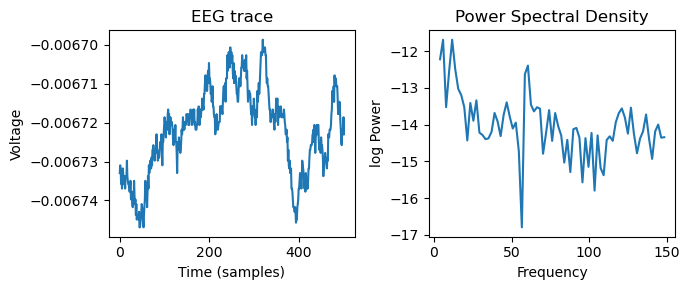

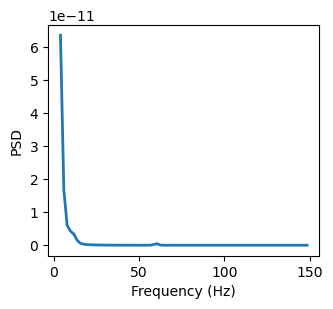

In [15]:
# Plot our results
%matplotlib inline

# Plot individual trial example
plt.figure(figsize=(7, 3))
ax = plt.subplot(121);
plt.plot(eeg.get_data()[10, 0, :])
plt.title('EEG trace')
plt.xlabel('Time (samples)')
plt.ylabel('Voltage')
ax = plt.subplot(122);
plt.plot(freqs, np.log10(psds[10, 0, :]))
plt.title('Power Spectral Density')
plt.xlabel('Frequency')
plt.ylabel('log Power')
plt.tight_layout()

# Average PSD without log-normalization
plt.figure(figsize=(3.5, 3))
ax = plt.subplot(111)
plt.plot(freqs, np.mean(psds[:, 0, :], 0), linewidth=2)
plt.ylabel('PSD')
plt.xlabel('Frequency (Hz)')

### What the plots show
- Top left (“EEG trace”): The raw EEG voltage over time. It looks noisy, but it contains rhythms of different frequencies mixed together.
- Top right (“Power Spectral Density – log power”): Shows how much “power” (signal energy) exists at each frequency, plotted on a logarithmic scale.
- Bottom (“PSD”): The same frequency-power relationship, but on a linear scale instead of log.

Note how the power at high frequencies is significantly smaller than at low frequencies. This is a classic relationship found in many natural signals, called the **"1/f"** phenomenon. It means that the amplitude of high-frequency signals tends to be much smaller than the amplitude of low-frequency signals. 

Unfortunately, this relationship makes it difficult to visualize changes at high frequencies, or properly assess differences between frequency bands. This is one reason why people often take the **log of power values before going forward with analyses**. Another reason is to transform non-normally distributed units of power (which are non-negative) to log-power, which are less drasatically non-normal.

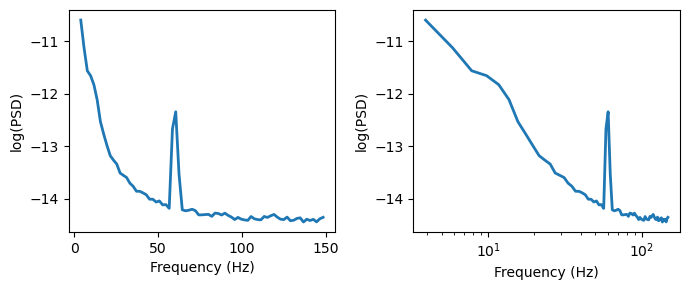

In [16]:
log_psds = np.log10(psds)

plt.figure(figsize=(7, 3))
ax = plt.subplot(121)
plt.plot(freqs, np.mean(log_psds[:, 0, :], 0), linewidth=2)
plt.ylabel('log(PSD)')
plt.xlabel('Frequency (Hz)');

# Plot on a log axis to better see low frequencies
ax = plt.subplot(122)
plt.semilogx(freqs, np.mean(log_psds[:, 0, :], 0), linewidth=2)
plt.ylabel('log(PSD)')
plt.xlabel('Frequency (Hz)');

plt.tight_layout()  #This cleans up our plots a bit

That's much better! We can better see things going on at all points throughout our frequency range. Note that there are several other ways to normalize power values -- some of which we will discuss -- that can also be applied after an initial log transform.

Now let's analyze 3 seconds of the power sectrum of the first channel for subject R1292E. What do you notice?

Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Used Annotations descriptions: ['COUNTDOWN_END', 'COUNTDOWN_START', 'DISTRACT_END', 'DISTRACT_START', 'ORIENT', 'PRACTICE_DISTRACT_END', 'PRACTICE_DISTRACT_START', 'PRACTICE_REC_END', 'PRACTICE_REC_START', 'PRACTICE_WORD', 'PROB', 'REC_END', 'REC_START', 'REC_WORD', 'SESS_START', 'START', 'STOP', 'TRIAL', 'WORD']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Loading data for

/home1/zrentala/COGS4290_DataMemoryBrains/dependencies/bidsreader/bidsreader/cmlbidsreader.py:203: RuntimeWarning: Omitted 1 annotation(s) that were outside data range.
  raw = read_raw_bids(bp)


0 bad epochs dropped
Effective window size : 0.512 (s)


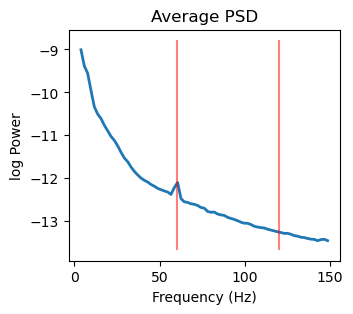

In [17]:
# Where's the primary noise component?
# sub = 'R1292E'
# task = 'FR1'
# sess = 0
sub = 'R1111M'
task = 'FR1'
sess = 0

reader = BIDSReader(root=root, subject=sub, task=task, session=0)

# Load the EEG as an mne object with word events only
word_evs = reader.load_events(event_type="ieeg").query('trial_type=="WORD"')
eeg = reader.load_epochs(tmin=0, tmax=3, events=word_evs, acquisition="monopolar", preload=True)
# Select the 62nd electrode.
eeg = eeg.pick(eeg.ch_names[0:1])
sfreq = eeg.info['sfreq']
psds, freqs = mne.time_frequency.psd_array_welch(eeg._data, sfreq, fmin=3, fmax=150)  #the output is size (events x channels x freqs)

plt.figure(figsize=(3.5, 3))
ax = plt.subplot(111)
plt.plot(freqs, np.log10(np.mean(psds[:, 0, :], 0)), linewidth=2)
plt.title('Average PSD')
plt.xlabel('Frequency (Hz)')
plt.ylabel('log Power')
plt.vlines([60, 120], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red', alpha=0.5)

Removed notch frequencies (Hz):
     60.00 :  288 windows
    120.00 :  288 windows
Effective window size : 0.512 (s)


Text(0.5, 1.0, 'Notch Filtered Data')

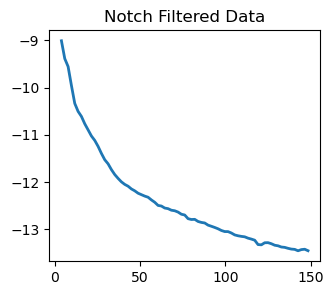

In [18]:
# Filtering out the noise and its harmonic

# spectrum_fit method
filt_data = mne.filter.notch_filter(eeg.get_data(), Fs=eeg.info['sfreq'], freqs=[60, 120],
                                    method='spectrum_fit')

# Get power spectral densities
# the output is size (events x channels x freqs)
psds, freqs = mne.time_frequency.psd_array_welch(filt_data, sfreq=eeg.info['sfreq'],
                                                 fmin=3, fmax=150)

plt.figure(figsize=(3.5, 3))
ax = plt.subplot(111)
plt.plot(freqs, np.log10(np.mean(psds[:, 0, :], 0)), linewidth=2)
plt.title('Notch Filtered Data')

Another alternative method is to use ptsa.data.filters.ButterworthFiler() in a similar manner. Read that function's documentation for details: https://pennmem.github.io/ptsa/html/api/data/filters.html.

### Performing a Morlet wavelet transform 
The wavelet transform is a powerful spectral decomposition method, since it explicitly lets us observe changes in the power spectrum over time. However, because this method involves convolving wavelets with our timeseries, we need to be sure to add buffers to either end of the signal (which we can clip off later). Otherwise, we'll end up eith edge effects that contaminate our results.

### What the plot's below show 
The plots below show the importance of z-scoring power values. The first plot is just a reflection of the 1/f phenomenon; however, the second graph is far more telling once the power values are z-scored. 

Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1111M/ses-0/ieeg/sub-R1111M_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Used Annotations descriptions: ['COUNTDOWN_END', 'COUNTDOWN_START', 'DISTRACT_END', 'DISTRACT_START', 'ORIENT', 'PRACTICE_DISTRACT_END', 'PRACTICE_DISTRACT_START', 'PRACTICE_REC_END', 'PRACTICE_REC_START', 'PRACTICE_WORD', 'PROB', 'REC_END', 'REC_START', 'REC_WORD', 'SESS_START', 'START', 'STOP', 'TRIAL', 'WORD']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Loading data for

/home1/zrentala/COGS4290_DataMemoryBrains/dependencies/bidsreader/bidsreader/cmlbidsreader.py:203: RuntimeWarning: Omitted 1 annotation(s) that were outside data range.
  raw = read_raw_bids(bp)


0 bad epochs dropped


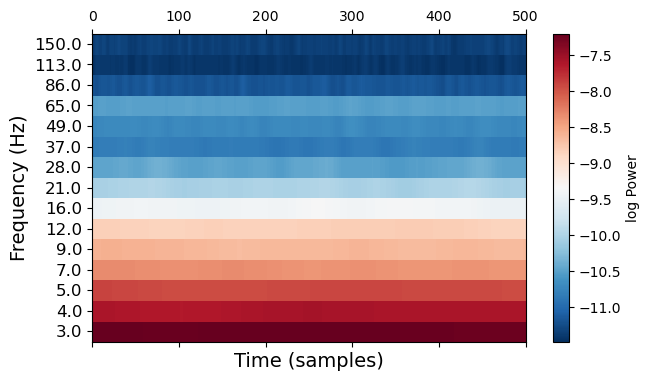

In [19]:
##### Load EEG

buf = 1  #define the buffer (in s) here. Should be at least half the total wavelet length at lowest frequency (i.e. 1/2f * n_cycles). With standard params, 1 sec usually suffices. 


# Specify which subject and experiment we want
sub = 'R1111M'
task = 'FR1'
sess = 0

reader = BIDSReader(root=root, subject=sub, task=task, session=0)

evs = reader.load_events(event_type="ieeg")
word_evs, _ = filter_events_df_by_trial_types(evs, "WORD")

# Load the EEG as an mne object.
eeg = reader.load_epochs(tmin=-buf, tmax=1+buf, events=word_evs, acquisition="monopolar", preload=True)
# Select the 62nd electrode.
eeg = eeg.pick(eeg.ch_names[62:63])

sr = eeg.info['sfreq'] #we'll need this soon

# Pre-define an array of frequencies.
# We can log-space them since wavelets are less sensitive to differences at higher frequencies
myfreqs = np.logspace(np.log10(3), np.log10(150), num=15)

# Run TF decomposition
# We're setting it to automatically average across trials
power = mne.time_frequency.tfr_morlet(eeg, freqs=myfreqs, n_cycles=5, return_itc=False, average=True)

# Plot results
plt.figure(figsize=(7., 4))
ax = plt.subplot(111)
# We're cutting off the buffers manually here
plt.matshow(np.log10(power.data[0, :, int(buf/1.*sr):-1*int(buf/1.*sr)]), fignum=0, aspect='auto', cmap='RdBu_r')
ax.invert_yaxis()
plt.yticks(np.arange(0, len(myfreqs)), np.round(myfreqs), fontsize=12)
plt.xlabel('Time (samples)', fontsize=14)
plt.ylabel('Frequency (Hz)', fontsize=14)
cb = plt.colorbar()
cb.set_label('log Power',)

This is nice, but we're not seeing much interesting activity because our color scale is still getting squished by the **overall** difference between low and high frequency power (despite our log transform). One way to address this is to normalize the data **within** each frequency by z-scoring across events. This will become important for future assignments when we discuss multivariate machine learning methods for analyzing this data.

Not setting metadata


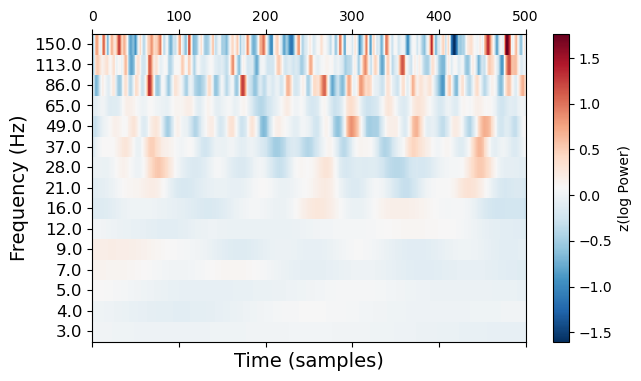

In [20]:
# Re compute power without averaging over events
power = mne.time_frequency.tfr_morlet(eeg, freqs=myfreqs, n_cycles=5, return_itc=False, average=False)

# Create an array of the mean and standard deviation of the power values across the session
power_data = power.data[:,:,:,int(buf/1.*sr):-1*int(buf/1.*sr)]
m = np.mean(np.mean(power_data,axis=3),axis=0)
m = np.expand_dims(np.expand_dims(m,axis=0),axis=3)
m = np.repeat(np.repeat(m,word_evs.shape[0],axis=0),power_data.shape[-1],axis=3)

sd = np.std(np.mean(power_data,axis=3),axis=0)
sd = np.expand_dims(np.expand_dims(sd,axis=0),axis=3)
sd = np.repeat(np.repeat(sd,word_evs.shape[0],axis=0),power_data.shape[-1],axis=3)

zpower_data = (power_data-m)/sd
zpower_data.shape

# Plot results
plt.figure(figsize=(7., 4))
ax = plt.subplot(111)
plt.matshow(np.mean(zpower_data[:,0, :,:],axis=0), fignum=0, aspect='auto', cmap='RdBu_r')
ax.invert_yaxis()
plt.yticks(np.arange(0, len(myfreqs)), np.round(myfreqs), fontsize=12)
plt.xlabel('Time (samples)', fontsize=14)
plt.ylabel('Frequency (Hz)', fontsize=14)
cb = plt.colorbar()
cb.set_label('z(log Power)',)

### Spectral Analysis in PTSA
The PTSA library was developed by the Computational Memory Lab to implement several key transforms useful in memory analysis. In particular, PTSA proides a fast implementation of the Morlet wavelet filter. Also relevant is its implementation of the Butterworth filter. Use of PTSA can be seen below!

#### What the plot's show
- The first plot is an unfiltered Power Spectral Analysis
- The second is the raw EEG used for that analysis
- The last plot has a Butterworth Filter applied to it, but is the same data. 

A Butterworth filter is a type of signal filter designed to smoothly remove unwanted frequencies while preserving the shape of the signal within the desired range. It’s often described as having a “maximally flat” frequency response in the passband — meaning it doesn’t introduce ripples or uneven amplification of certain frequencies.

In [21]:
# events from epochs (relative)
ep_samples = eeg.events[:, 0].astype(int)

# samples from evs for the same trial type (absolute)
ev_samples = evs.loc[evs.trial_type == "WORD", "sample"].to_numpy(int)

print("n_epochs:", len(ep_samples), "n_evs_WORD:", len(ev_samples))

n_epochs: 288 n_evs_WORD: 288


In [22]:
# if they align 1:1 by order:
offset = ev_samples[0] - ep_samples[0]
print("offset guess:", offset)

# sanity check: does this offset map many?
mapped = ep_samples + offset
print("matches after offset:", np.isin(mapped, ev_samples).sum(), "of", len(ep_samples))

offset guess: 0
matches after offset: 288 of 288


In [23]:
# load EEG

sub = 'R1123C'
task = 'FR1'
sess = 0

range_left_ms = 1
range_right_ms = 2
morlet_reps = 6

reader = BIDSReader(root=root, subject=sub, task=task, session=sess)
pairs = reader.load_combined_channels("bipolar")
evs = reader.load_events(event_type="ieeg")
enc_evs = evs[evs.trial_type == "WORD"].iloc[:25]

eeg = reader.load_epochs(
    tmin=-range_left_ms,
    tmax=range_right_ms,
    acquisition="bipolar",
    preload=True,
)

eeg_subset = eeg[:len(enc_evs)]

eeg_ptsa = mne_epochs_to_ptsa(epochs=eeg_subset, events=enc_evs)

Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1123C/ses-0/ieeg/sub-R1123C_ses-0_task-FR1_acq-bipolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1123C/ses-0/ieeg/sub-R1123C_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1123C/ses-0/ieeg/sub-R1123C_ses-0_task-FR1_acq-bipolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1123C/ses-0/ieeg/sub-R1123C_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Used Annotations descriptions: ['COUNTDOWN_END', 'COUNTDOWN_START', 'DISTRACT_END', 'DISTRACT_START', 'ORIENT', 'PRACTICE_DISTRACT_END', 'PRACTICE_DISTRACT_START', 'PRACTICE_REC_END', 'PRACTICE_REC_START', 'PRACTICE_WORD', 'PROB', 'REC_END', 'REC_START', 'REC_WORD', 'SESS_START', 'START', 'STOP', 'TRIAL', 'WORD']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metada

/home1/zrentala/COGS4290_DataMemoryBrains/dependencies/bidsreader/bidsreader/cmlbidsreader.py:115: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage, on_missing="ignore")


1 bad epochs dropped


In [24]:
eeg_chan = eeg_ptsa.sel(channel=['TO8-TO9', 'OF3-OF4'])
freqs = np.unique(np.logspace(np.log10(1), np.log10(300), 72))

# compute spectral features!
wf = morlet.MorletWaveletFilter(freqs=freqs, width=morlet_reps, output='power', complete=True)
# freqs, events, elecs, and time
powers = wf.filter(eeg_chan)

# remove buffers
powers = powers.isel(time=powers.time>0)
powers = powers.isel(time=powers.time<1)

CPP total time wavelet loop:  0.1480720043182373


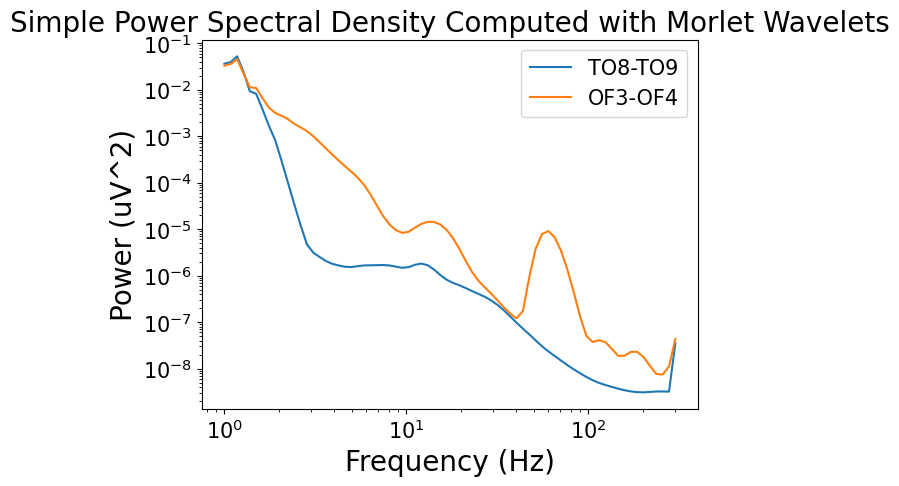

In [25]:
# compute simple PSD by averaging over time and events
psd = powers.mean('time').mean('event')
for chan in psd.channel:
    plt.loglog(psd.frequency, psd.sel(channel=chan), label=chan.item())

plt.legend(fontsize=15)
plt.title('Simple Power Spectral Density Computed with Morlet Wavelets', fontsize=20)
plt.xlabel('Frequency (Hz)', fontsize=20)
plt.ylabel('Power (uV^2)', fontsize=20)
_ = plt.xticks(fontsize=15)
_ = plt.yticks(fontsize=15)

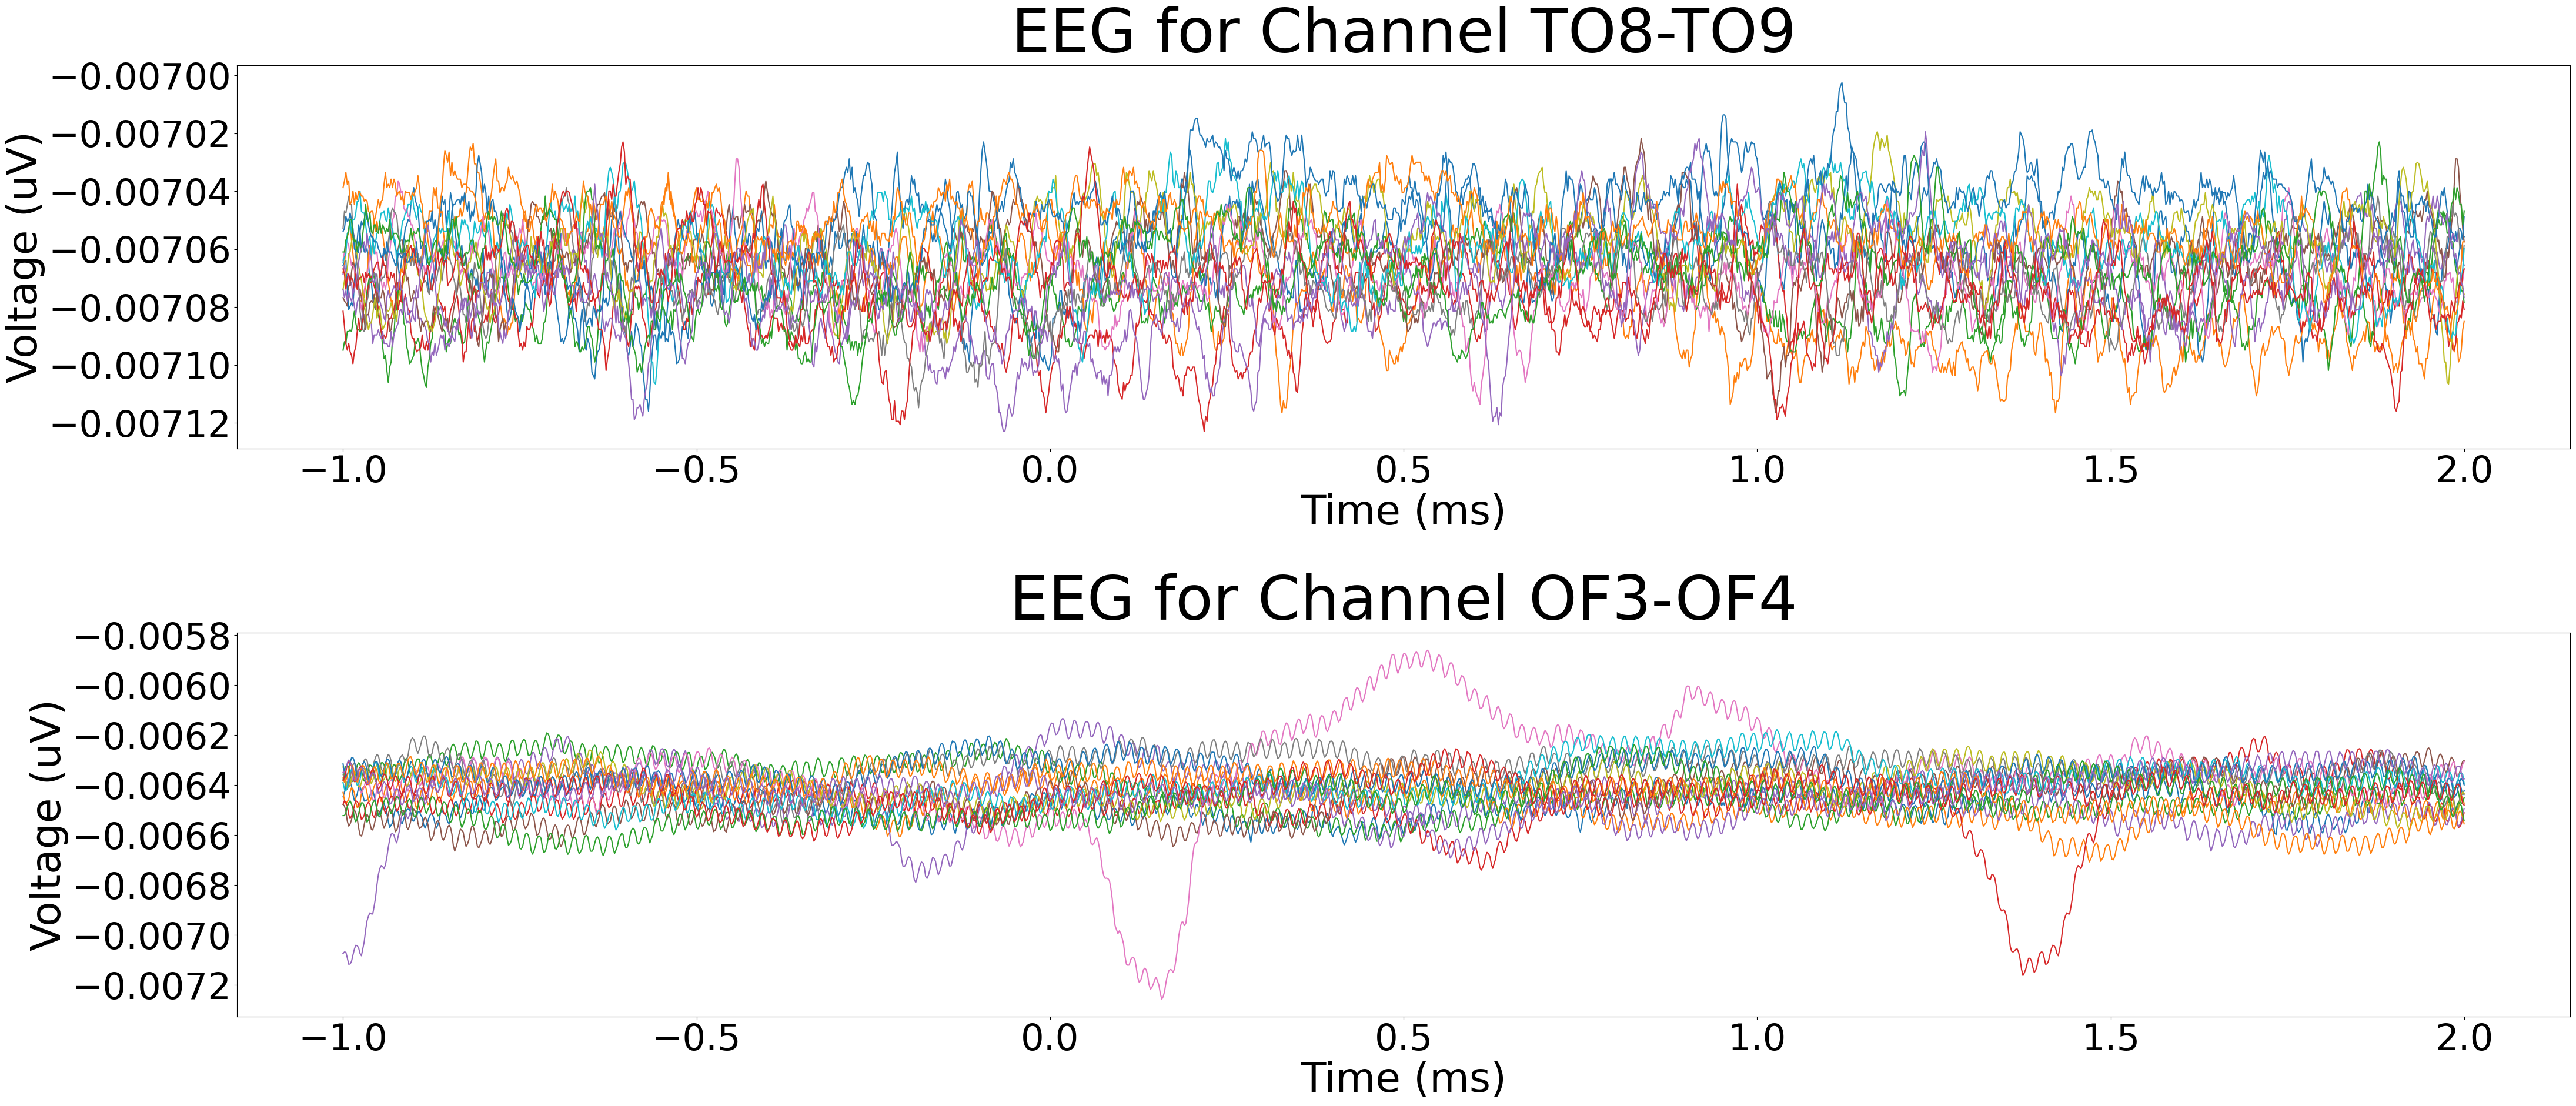

In [26]:
fig = plt.figure(figsize=(45, 20))
for i, ch in enumerate(eeg_chan.channel):
    eeg_ch = eeg_chan.sel(channel=ch)
    plt.subplot(2, 1, i + 1)
    plt.title(f'EEG for Channel {ch.item()}', fontsize=75)
    plt.xlabel('Time (ms)', fontsize=50)
    plt.ylabel('Voltage (uV)', fontsize=50)
    plt.xticks(fontsize=45)
    plt.yticks(fontsize=45)
    # plot traces
    for ev in eeg_ch.event[:15]:
        plt.plot(eeg_ch.time, eeg_ch.sel(event=ev))
fig.tight_layout(pad=5.0)

CPP total time wavelet loop:  0.19523143768310547


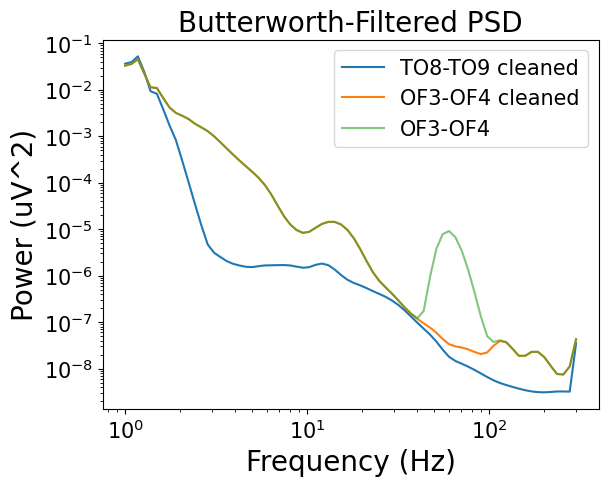

In [27]:
# clean up line noise at 60 Hz from power grid just as before, but with PTSA
freq_range = [58., 62.]
b_filter = ButterworthFilter(freq_range=freq_range, filt_type='stop', order=4)
eeg_filtered = b_filter.filter(eeg_chan)

# compute spectral features!
wf = morlet.MorletWaveletFilter(freqs=freqs, width=morlet_reps, output='power', complete=True)
# freqs, events, elecs, and time
powers = wf.filter(eeg_filtered)

# remove buffers
powers = powers.isel(time=powers.time>0)
powers = powers.isel(time=powers.time<1)

psd_filtered = powers.mean('time').mean('event')
for chan in psd.channel:
    plt.loglog(psd_filtered.frequency, psd_filtered.sel(channel=chan), label=chan.item() + ' cleaned')
plt.loglog(psd.frequency, psd.sel(channel='OF3-OF4'), label=chan.item(), alpha=0.6)

plt.legend(fontsize=15)
plt.title('Butterworth-Filtered PSD', fontsize=20)
plt.xlabel('Frequency (Hz)', fontsize=20)
plt.ylabel('Power (uV^2)', fontsize=20)
_ = plt.xticks(fontsize=15)
_ = plt.yticks(fontsize=15)